### Imports

In [1]:
# Import des outils de tables
import numpy as np
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt

# Import des outils de machine learning
from sklearn.model_selection import GridSearchCV, train_test_split

# Import des modèles
from xgboost import XGBRegressor
from tabicl import TabICLRegressor  # https://github.com/soda-inria/tabicl
from sklearn.ensemble import RandomForestRegressor

# Import des métriques d'évaluation
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Options d'affichage
from IPython.display import clear_output, display

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Téléchargement du dataset

In [2]:
df = kagglehub.dataset_load(
    kagglehub.KaggleDatasetAdapter.PANDAS,
    "mirichoi0218/insurance",
    "insurance.csv"
)

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### Séparation en train, test

In [3]:
# Variables explicatives
X = df.iloc[:, :-1]

# Conversion des variables catégorielles en variables numériques (One-Hot Encoding)
X = pd.get_dummies(X, drop_first=True, dtype=float)

# Variable à prédire
y = df.iloc[:, -1]  # df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1070, 8)
(268, 8)
(1070,)
(268,)


### Introduction de valeurs manquantes

In [4]:
def ajouter_nan(df, proportion=0.10, colonnes=None, seed=42):
    resultat = df.copy()

    if colonnes is None:
        colonnes = resultat.columns.tolist()

    sous_df = resultat[colonnes]
    cellules_valides = np.argwhere(sous_df.notna().to_numpy())

    rng = np.random.default_rng(seed)
    nombre = round(proportion * len(cellules_valides))

    cellules_choisies = rng.choice(
        len(cellules_valides),
        size=nombre,
        replace=False
    )

    masque = np.zeros(sous_df.shape, dtype=bool)
    lignes, cols = cellules_valides[cellules_choisies].T
    masque[lignes, cols] = True

    resultat[colonnes] = sous_df.mask(masque)

    # Utile pour savoir quelles valeurs ont été artificiellement supprimées
    masque = pd.DataFrame(
        masque,
        index=df.index,
        columns=colonnes
    )

    return resultat, masque

### Préparation du tableau des scores

In [5]:
modeles = ["TFM (TabICL)", "Random Forest", "XGBoost"]
metriques = ["MAE", "MSE", "RMSE", "R²"]
proportions_nan = np.linspace(0.0, 0.99, 100)

colonnes_resultats = pd.MultiIndex.from_product(
    [modeles, metriques],
    names=["Modèle", "Métrique"]
)

resultats = pd.DataFrame(
    index=proportions_nan,
    columns=colonnes_resultats,
    dtype=float
)
resultats.index.name = "Proportion de NaN"

param_grid = {
    "n_estimators": [100, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 4, 5],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

meilleurs_parametres_xgb = pd.DataFrame(
    index=proportions_nan,
    columns=param_grid.keys()
)
meilleurs_parametres_xgb.index.name = "Proportion de NaN"

### Prédictions & Évaluation des résultats

In [6]:
def calculer_metriques(y_reel, y_prediction):
    mse = mean_squared_error(y_reel, y_prediction)

    return [
        mean_absolute_error(y_reel, y_prediction),
        mse,
        np.sqrt(mse),
        r2_score(y_reel, y_prediction)
    ]


for proportion in resultats.index:

    # Même jeu d'entraînement dégradé pour les trois modèles
    X_train_emmental, _ = ajouter_nan(X_train, proportion)

    # Tabular Foundation Model
    model_tfm = TabICLRegressor()
    model_tfm.fit(X_train_emmental, y_train)
    y_pred_tfm = model_tfm.predict(X_test)

    # Random Forest
    model_rf = RandomForestRegressor(random_state=42)
    model_rf.fit(X_train_emmental, y_train)
    y_pred_rf = model_rf.predict(X_test)

    # XGBoost
    grid_xgb = GridSearchCV(
        XGBRegressor(
            random_state=42,
            objective="reg:squarederror"
        ),
        param_grid,
        cv=5,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )
    grid_xgb.fit(X_train_emmental, y_train)
    y_pred_xgb = grid_xgb.predict(X_test)

    # Stockage des scores et des meilleurs paramètres XGBoost
    resultats.loc[proportion, ("TFM (TabICL)", slice(None))] = calculer_metriques(
        y_test, y_pred_tfm
    )
    resultats.loc[proportion, ("Random Forest", slice(None))] = calculer_metriques(
        y_test, y_pred_rf
    )
    resultats.loc[proportion, ("XGBoost", slice(None))] = calculer_metriques(
        y_test, y_pred_xgb
    )
    meilleurs_parametres_xgb.loc[proportion] = [
        grid_xgb.best_params_[parametre]
        for parametre in meilleurs_parametres_xgb.columns
    ]

    clear_output(wait=True)
    print(f"Proportion de NaN traitée : {proportion:.0%}")
    display(
        resultats.loc[proportion]
                 .unstack(level="Métrique")
                 .loc[modeles, metriques]
    )

Proportion de NaN traitée : 99%


Métrique,MAE,MSE,RMSE,R²
Modèle,,,,
TFM (TabICL),7996.725374,1.243461e+08,11151.057299,0.199053
Random Forest,9189.500510,1.604662e+08,12667.526779,-0.033607
XGBoost,8172.547598,1.449219e+08,12038.350652,0.066518


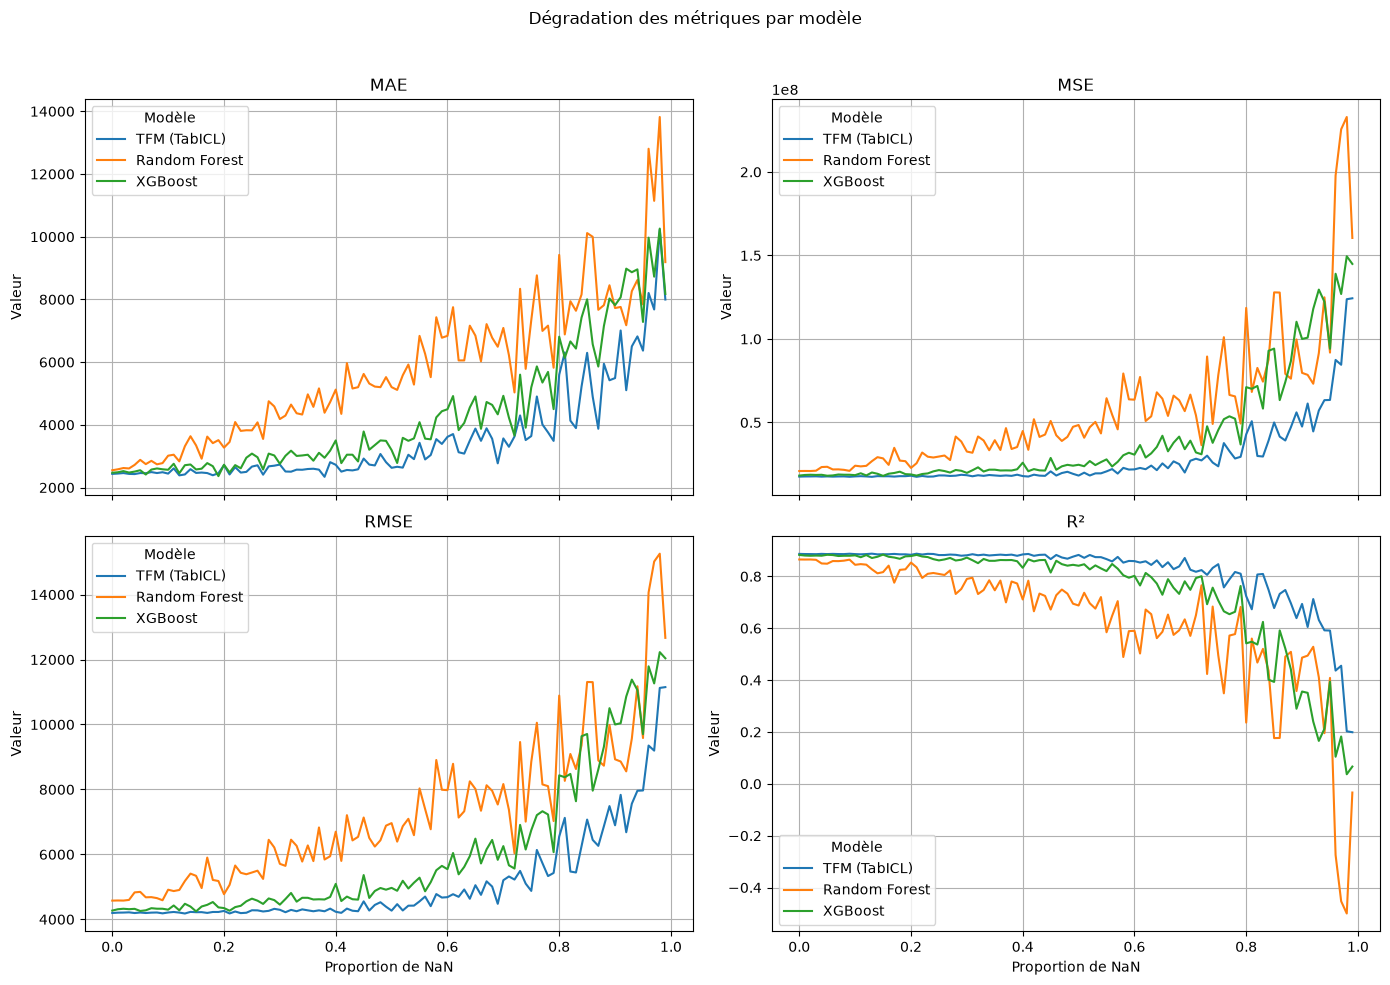

In [7]:
resultats_float = resultats.astype(float)

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True)

for axe, metrique in zip(axes.flat, metriques):
    resultats_float.xs(
        metrique, axis=1, level="Métrique"
    ).plot(ax=axe)
    axe.set_title(metrique)
    axe.set_xlabel("Proportion de NaN")
    axe.set_ylabel("Valeur")
    axe.grid(True)

fig.suptitle("Dégradation des métriques par modèle")
fig.tight_layout(rect=(0, 0, 1, 0.96))
plt.show()